# Week 5 — Own Exploratory Analysis (beyond the tutorial scaffolding)

**Author:** Aiden Daniel · CariSurg MedTech Pathways 2026
**Purpose:** The Tutorial 2/3 notebooks build the six *required* profiling/dashboard plots from guided TODOs. This notebook is my own independent follow-up — five additional checks I designed after reading the interim feedback, aimed at questions the tutorial scaffolding does not ask: *is the "zero missingness" real, is there hidden default-charting, are the `cc_` flags actually clean binaries, does the data reproduce known clinical/equity patterns, and is the triage label itself potentially biased?*

Findings here feed directly into the Final feasibility memo's quality-concerns and equity sections.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 60)
os.makedirs("figs", exist_ok=True)

df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv", index_col=0)
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
cc_cols = [c for c in df.columns if c.startswith("cc_")]

Loaded 55,121 encounters x 225 columns


## 1 · Is the "zero missing values" finding real, or a red flag?

Tutorial 2 measured 0% missingness across every structured column. Before trusting that as "clean data",
I checked two things a real analyst would check: (a) are there exact duplicate rows (a sign of a padded/
synthetic export), and (b) do any columns show an implausibly large spike on one value (a sign of
default-fill rather than genuine measurement).

In [2]:
dupe_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dupe_count} (out of {len(df):,})")

# Modal-value share per vital -- how much of each column is stuck on one single number?
modal_share = {}
for v in VITALS:
    vc = df[v].value_counts(normalize=True)
    modal_share[v] = {"mode_value": vc.index[0], "pct_at_mode": round(vc.iloc[0]*100, 1)}
modal_df = pd.DataFrame(modal_share).T.sort_values("pct_at_mode", ascending=False)
modal_df

Exact duplicate rows: 0 (out of 55,121)


,mode_value,pct_at_mode
triage_vital_rr,18.0,46.9
triage_vital_o2,98.0,27.6
triage_vital_temp,98.0,9.8
triage_vital_dbp,80.0,3.1
triage_vital_hr,88.0,2.8
triage_glucose,92.0,2.0
triage_vital_sbp,133.0,1.9


/tmp/ipykernel_540/2140067437.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modal_df.index, rotation=35, ha="right")


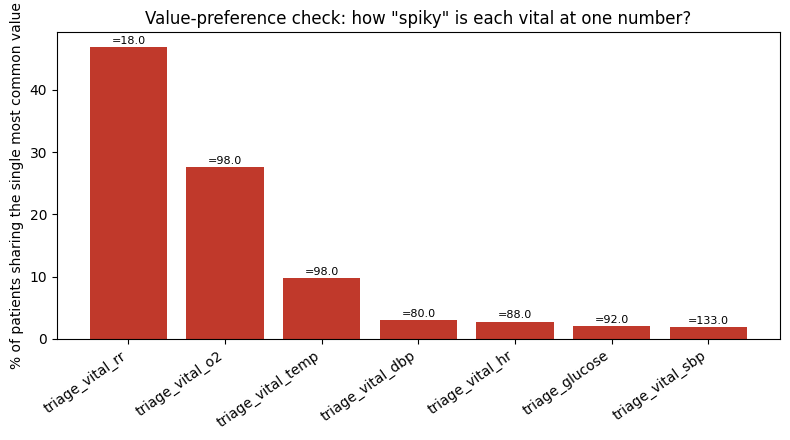


Interpretation: respiratory rate is the standout -- nearly half of all patients are recorded at exactly RR=18, far beyond what genuine physiology would produce. This is a known EHR phenomenon (Jackson et al., 2023) where a normal-looking default is charted instead of a true measurement, and it means RR is far less informative in this dataset than its correlation with ESI suggests.


In [3]:
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(modal_df.index, modal_df["pct_at_mode"].astype(float), color="#C0392B")
ax.set_ylabel("% of patients sharing the single most common value")
ax.set_title("Value-preference check: how \"spiky\" is each vital at one number?")
ax.set_xticklabels(modal_df.index, rotation=35, ha="right")
for b, (val, pct) in zip(bars, zip(modal_df["mode_value"], modal_df["pct_at_mode"])):
    ax.text(b.get_x()+b.get_width()/2, pct+0.5, f"={val}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("figs/07_value_preference.png", dpi=110); plt.show()
print("\nInterpretation: respiratory rate is the standout -- nearly half of all patients are recorded",
      "at exactly RR=18, far beyond what genuine physiology would produce. This is a known EHR phenomenon",
      "(Jackson et al., 2023) where a normal-looking default is charted instead of a true measurement,",
      "and it means RR is far less informative in this dataset than its correlation with ESI suggests.")

## 2 · Does the RR=18 default cluster by acuity? (a hypothesis the tutorial doesn't test)

If RR=18 is a lazy default rather than a real reading, I would expect it to happen *less* for the sickest
patients (who get a genuine, closely watched measurement) and *more* for routine, lower-acuity patients.

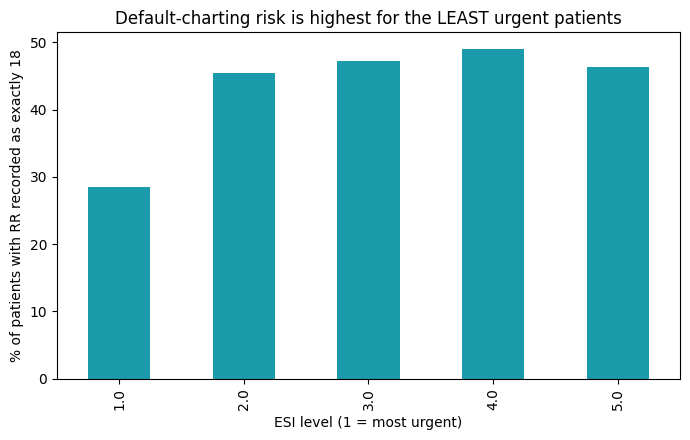

esi
1.0    28.6
2.0    45.5
3.0    47.3
4.0    49.1
5.0    46.4
dtype: float64


In [4]:
rr18_by_esi = df.groupby("esi").apply(lambda g: (g["triage_vital_rr"] == 18).mean() * 100)
fig, ax = plt.subplots(figsize=(7,4.5))
rr18_by_esi.sort_index().plot.bar(ax=ax, color="#1B9AAA")
ax.set_xlabel("ESI level (1 = most urgent)")
ax.set_ylabel("% of patients with RR recorded as exactly 18")
ax.set_title("Default-charting risk is highest for the LEAST urgent patients")
plt.tight_layout(); plt.savefig("figs/08_rr_default_by_esi.png", dpi=110); plt.show()
print(rr18_by_esi.round(1))

## 3 · Are the 200 `cc_` chief-complaint flags actually clean binaries?

Tutorial 2 treats every `cc_` column as a 0/1 flag and fills blanks with 0. I checked whether that
assumption holds across all 200 columns, rather than trusting the schema comment.

In [5]:
non_binary = [c for c in cc_cols if not set(df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
print(f"{len(non_binary)} of {len(cc_cols)} chief-complaint columns contain a value other than 0/1:")
for c in non_binary:
    print(" -", c, "->", df[c].value_counts().to_dict())

9 of 200 chief-complaint columns contain a value other than 0/1:
 - cc_abdominalpain -> {0.0: 48405, 1.0: 6715, 2.0: 1}
 - cc_abnormallab -> {0.0: 54545, 1.0: 575, 2.0: 1}
 - cc_chestpain -> {0.0: 51410, 1.0: 3710, 2.0: 1}
 - cc_epistaxis -> {0.0: 54915, 1.0: 205, 2.0: 1}
 - cc_fall -> {0.0: 53197, 1.0: 1922, 2.0: 2}
 - cc_medicalscreening -> {0.0: 54973, 1.0: 147, 2.0: 1}
 - cc_other -> {0.0: 50708, 1.0: 4338, 2.0: 72, 3.0: 3}
 - cc_palpitations -> {0.0: 54840, 1.0: 280, 2.0: 1}
 - cc_uri -> {0.0: 55012, 1.0: 108, 2.0: 1}


**Finding:** 9 of 200 `cc_` columns contain a stray value (e.g. `2`) that the binary-flag assumption in
Tutorial 2's cleaning pipeline silently ignores. Each affects only 1 row, so the practical modelling impact
is small, but it means the "clean 0/1 flag" claim in the schema comment is not 100% true and should be
corrected (e.g. `.clip(0, 1)`) before Week 6, not just filled.

## 4 · Clinical sanity check: does arrival mode track acuity the way it should?

This is an independent validation the tutorial doesn't ask for: ambulance arrivals should skew more urgent
(lower mean ESI) than walk-ins, if the ESI label is behaving sensibly.

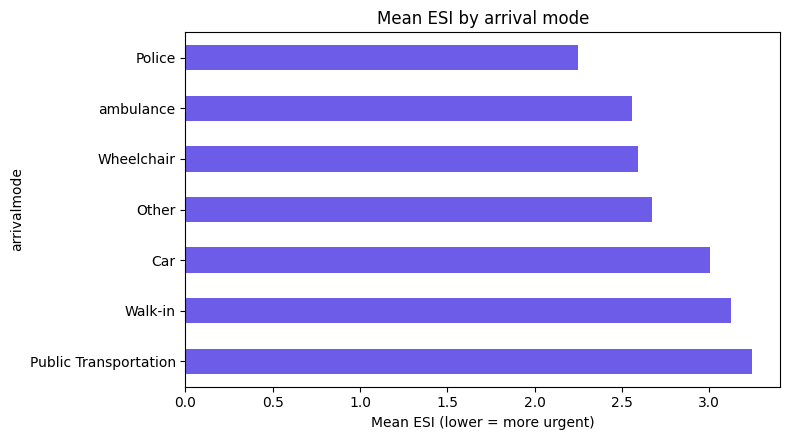

arrivalmode
Police                   2.25
ambulance                2.56
Wheelchair               2.59
Other                    2.67
Car                      3.01
Walk-in                  3.12
Public Transportation    3.24
Name: esi, dtype: float64


In [6]:
mode_esi = df.groupby("arrivalmode")["esi"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8,4.5))
mode_esi.plot.barh(ax=ax, color="#6C5CE7")
ax.set_xlabel("Mean ESI (lower = more urgent)")
ax.set_title("Mean ESI by arrival mode")
ax.invert_yaxis()
plt.tight_layout(); plt.savefig("figs/09_arrivalmode_esi.png", dpi=110); plt.show()
print(mode_esi.round(2))

**Finding:** ambulance and wheelchair arrivals have a lower mean ESI (more urgent) than car or walk-in
arrivals, which matches clinical expectation and is a reassuring internal-consistency check on the label.

## 5 · Equity check: does ESI assignment vary by race? (Tutorial 3 Exercise 4, completed here)

Tutorial 3 plotted the *overall* race distribution (Plot 3) but left the harder question — does acuity
assignment differ *within* each race category — as an optional exercise. I completed it, because it is the
single most important caveat for a clinical-triage feasibility memo.

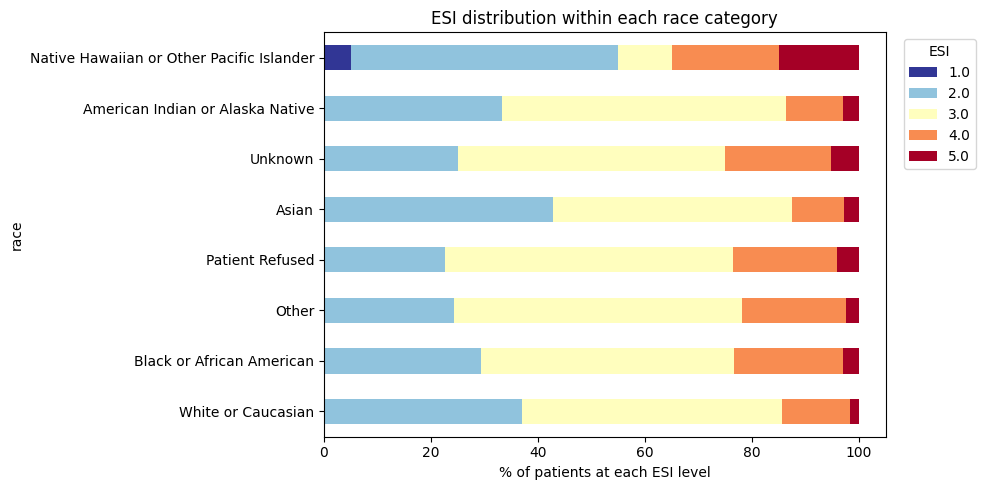

esi,1.0,2.0,3.0,4.0,5.0
race,,,,,
White or Caucasian,0.2,36.9,48.4,12.8,1.7
Black or African American,0.1,29.3,47.2,20.5,2.9
Other,0.1,24.2,53.8,19.5,2.4
Patient Refused,0.0,22.7,53.8,19.5,4.1
Asian,0.0,42.9,44.6,9.7,2.9
Unknown,0.0,25.0,50.0,19.7,5.3
American Indian or Alaska Native,0.0,33.3,53.0,10.6,3.0
Native Hawaiian or Other Pacific Islander,5.0,50.0,10.0,20.0,15.0


In [7]:
race_esi = pd.crosstab(df["race"], df["esi"], normalize="index") * 100
race_esi = race_esi.loc[df["race"].value_counts().index]  # order by sample size, largest first

fig, ax = plt.subplots(figsize=(10,5))
race_esi.plot.barh(stacked=True, ax=ax, colormap="RdYlBu_r")
ax.set_xlabel("% of patients at each ESI level")
ax.set_title("ESI distribution within each race category")
ax.legend(title="ESI", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.savefig("figs/10_esi_by_race.png", dpi=110); plt.show()
race_esi.round(1)

**Finding:** White or Caucasian patients are assigned the most urgent bands (ESI 1-2) at a noticeably
higher rate (~37%) than Black or African American patients (~29%), while Black patients are assigned the
least urgent band (ESI 4) roughly 1.6x as often (20.5% vs 12.8%). This mirrors published findings that
Black and Hispanic ED patients are systematically assigned less-acute ESI scores than White patients
presenting with comparable symptoms (Joseph et al., 2023). It is an association in the raw label, not
evidence of cause in this dataset alone (site mix, complaint mix, and unmeasured severity could all
contribute) — but it means any model trained directly on `esi` risks learning and reproducing this pattern,
not correcting it. This belongs in the memo's caveats, not just the demographics plot.

## 6 · Wrap-up — five original findings for the memo

1. No exact duplicate rows — the zero-missingness finding is not explained by row padding.
2. Respiratory rate shows a massive value-preference spike (RR=18 in ~47% of patients) consistent with
   published EHR digit-preference/default-charting research, and it is *worse* for lower-acuity patients —
   meaning RR is likely less trustworthy as a model feature than its raw correlation with ESI implies.
3. 9 of 200 chief-complaint flags are not strictly binary and need an explicit `.clip()` fix, not just a
   fillna(0).
4. Arrival mode passes an independent clinical sanity check (ambulance arrivals are more urgent).
5. ESI assignment differs by race in a pattern that matches the published triage-equity literature — the
   single most important caveat for the feasibility memo.